### What is Hypothesis Testing?
Hypothesis testing is a way to use sample data to decide whether a claim about a population is likely true or not, using statistics instead of guesswork.

##### The Basic Idea

You start with two competing statements:

Null Hypothesis (H0): The "nothing special is happening" statement. Assumes no effect, no difference, or that a claim is false until proven otherwise.
Alternative Hypothesis (H1 or Ha): What you're actually trying to find evidence for. The claim you suspect might be true.

You then collect sample data and ask: "If H0 were true, how likely is it that I'd see data like this?" If the answer is "very unlikely," you reject H0 in favor of H1.

***The Step-by-Step Process***

1. State the hypotheses
Example: A shop claims average daily production exceeds 500.

H0: μ ≤ 500
H1: μ > 500

2. Choose a significance level (alpha)
This is your threshold for "unlikely enough to matter." Usually 0.05 (5%), meaning you're willing to accept a 5% chance of being wrong when you reject H0.

3. Pick the right test
Depends on your data:

z-test: population standard deviation known, larger samples
t-test: population standard deviation unknown, using sample standard deviation instead

4. Calculate the test statistic
This measures how far your sample result is from what H0 predicts, in standard error units. Example: a z-score of 2.01 means your sample mean is about 2 standard errors above the assumed value.

5. Find the p-value or compare to a critical value

p-value approach: the probability of getting a result this extreme (or more) if H0 were true
critical value approach: a fixed cutoff score; if your test statistic goes past it, you're in the "reject H0" zone

Both approaches give the same decision, just from different directions.

6. Make a decision

If p-value < alpha (or test statistic passes the critical value) → reject H0
If p-value ≥ alpha → fail to reject H0

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm
from scipy.stats import ttest_1samp, ttest_ind

In [2]:
# sample dataset created
group_a = np.random.normal(loc=70, scale=8, size=40)   # traditional method
group_b = np.random.normal(loc=75, scale=8, size=40)   # new method

df = pd.DataFrame({
    "score": np.concatenate([group_a, group_b]),
    "group": ["A_traditional"] * len(group_a) + ["B_new_method"] * len(group_b)
})
df

,score,group
0,75.558684,A_traditional
1,80.456508,A_traditional
2,72.417497,A_traditional
3,59.438028,A_traditional
4,75.128654,A_traditional
...,...,...
75,87.142469,B_new_method
76,78.933444,B_new_method
77,77.560236,B_new_method
78,83.775505,B_new_method


Scenario: a teacher wants to know if a new teaching method improves test scores.
- **Group A** = students taught with the traditional method
- **Group B** = students taught with the new method

We'll simulate exam scores for 40 students in each group.

In [3]:
summary = df.groupby("group")["score"].agg(["count", "mean", "std", "min", "max"])
summary

,count,mean,std,min,max
group,,,,,
A_traditional,40,70.114750,8.524879,51.969975,88.736246
B_new_method,40,77.006729,7.109570,62.413493,89.988305


C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\dell\anaconda3\lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-

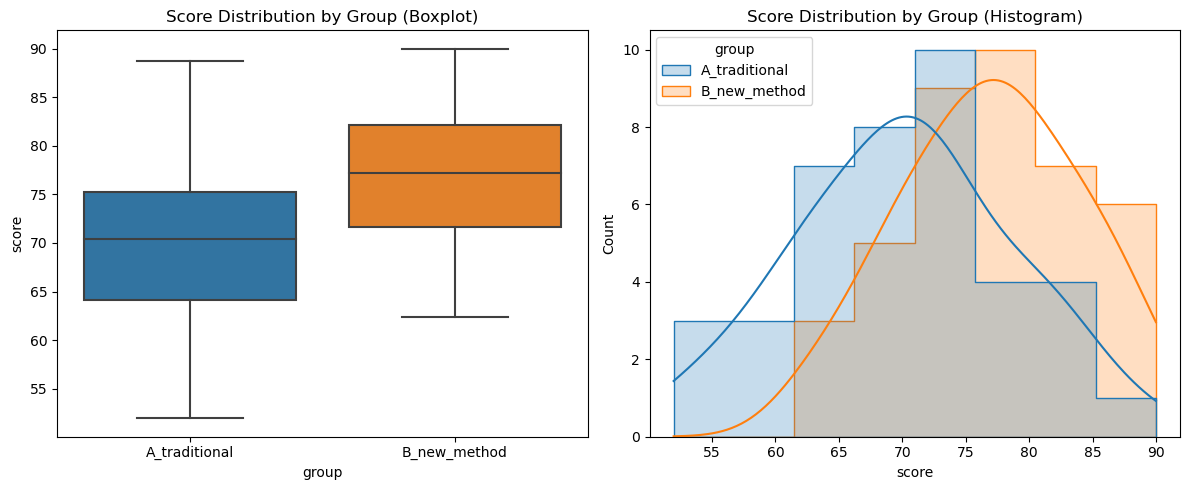

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x="group", y="score", ax=axes[0])
axes[0].set_title("Score Distribution by Group (Boxplot)")

sns.histplot(data=df, x="score", hue="group", kde=True, ax=axes[1], element="step")
axes[1].set_title("Score Distribution by Group (Histogram)")

plt.tight_layout()
plt.show()

Check Test Assumptions

The independent t-test assumes:
1. Each group is roughly **normally distributed** (Shapiro-Wilk test)
2. The two groups have roughly **equal variance** (Levene's test)


In [5]:
shapiro_a = stats.shapiro(group_a)
shapiro_b = stats.shapiro(group_b)
levene_test = stats.levene(group_a, group_b)

print(f"Shapiro-Wilk (Group A): stat={shapiro_a.statistic:.3f}, p={shapiro_a.pvalue:.3f}")
print(f"Shapiro-Wilk (Group B): stat={shapiro_b.statistic:.3f}, p={shapiro_b.pvalue:.3f}")
print(f"Levene's test (equal variance): stat={levene_test.statistic:.3f}, p={levene_test.pvalue:.3f}")

print("\nInterpretation:")
print("- Shapiro p > 0.05 => normality assumption is reasonable")
print("- Levene p > 0.05  => equal variance assumption is reasonable")

Shapiro-Wilk (Group A): stat=0.991, p=0.980
Shapiro-Wilk (Group B): stat=0.985, p=0.855
Levene's test (equal variance): stat=0.838, p=0.363

Interpretation:
- Shapiro p > 0.05 => normality assumption is reasonable
- Levene p > 0.05  => equal variance assumption is reasonable


State the Hypotheses

- **H0:** The mean score of Group A equals the mean score of Group B (no real difference)
- **H1:** The mean score of Group A differs from the mean score of Group B

We'll use **alpha = 0.05**.

In [6]:
# run the t-test
alpha = 0.05

# equal_var is set based on the Levene's test result above
equal_var = levene_test.pvalue > 0.05
t_stat, p_value = stats.ttest_ind(group_a, group_b, equal_var=equal_var)

print(f"Using {'Student' if equal_var else 'Welch'} t-test (equal_var={equal_var})")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value     = {p_value:.4f}")

Using Student t-test (equal_var=True)
t-statistic = -3.9268
p-value     = 0.0002


In [7]:
if p_value < alpha:
    conclusion = "Reject H0: there IS a statistically significant difference between the two groups."
else:
    conclusion = "Fail to reject H0: there is NOT enough evidence of a difference between the two groups."

mean_diff = group_b.mean() - group_a.mean()

print(f"Mean(Group A) = {group_a.mean():.2f}")
print(f"Mean(Group B) = {group_b.mean():.2f}")
print(f"Mean difference (B - A) = {mean_diff:.2f}")
print(f"p-value = {p_value:.4f}  (alpha = {alpha})")
print()
print(conclusion)

Mean(Group A) = 70.11
Mean(Group B) = 77.01
Mean difference (B - A) = 6.89
p-value = 0.0002  (alpha = 0.05)

Reject H0: there IS a statistically significant difference between the two groups.


1) A french cake shop claims that the average number of pastries they can produce in a day exceeds 500. The average number of pastries produced per day over a 70 day period was found to be 530. Assume that the population standard deviation for the pastries produced per day is 125. 


2) Test the claim using a z-test with the critical z-value = 1.64 at the alpha (significance level) = 0.05, and state your interpretation.

In [8]:
# H0: mu = 500
# H1: mu > 500
z = (530-500)/(125/np.sqrt(70))
z

2.007984063681781

In [11]:
p = 1-norm.cdf(z)
p

0.022322492581293485

In [12]:
alpha = 0.05
if p < alpha:
    print("reject H0")
else:
    print("Do not reject H0")

reject H0


In [13]:
n = norm.ppf(0.95)
n

1.6448536269514722

In [14]:
x = 500 + z*125/(np.sqrt(70))
x

530.0

In [15]:
1- norm.cdf((524.57-500)/(125/np.sqrt(70)))

0.05003246299932018

In [16]:
1- norm.cdf((540-500)/(125/np.sqrt(70)))

0.0037107735265998754

In [20]:
df_iq = pd.read_csv('C://Users//dell//Downloads//iq_two_schools.csv')
df_iq

,School,iq
0,school_1,91
1,school_1,95
2,school_1,110
3,school_1,112
4,school_1,115
5,school_1,94
6,school_1,82
7,school_1,84
8,school_1,85
9,school_1,89


In [21]:
df_iq.groupby("School")["iq"].mean()

School
school_1    101.153846
school_2    109.416667
Name: iq, dtype: float64

In [22]:
iq_1 = df_iq[df_iq["School"]=="school_1"]["iq"]
iq_2 = df_iq[df_iq["School"]=="school_2"]["iq"]

In [25]:
# H0 : mu1 = mu2
# Ha : mu1 != mu2

t, p = ttest_ind(iq_1, iq_2)

In [26]:
p

0.02004552710936217

In [27]:
t

-2.4056474861512704

In [28]:
alpha = 0.05
# Reject H0
# H0 : mu1 = mu2
# Ha : mu1 > mu2
ttest_ind(iq_1, iq_2, alternative="greater")

TtestResult(statistic=-2.4056474861512704, pvalue=0.9899772364453189, df=48.0)

In [30]:
# H0 : mu1 = mu2
# Ha : mu1 < mu2
t, p = ttest_ind(iq_1, iq_2, alternative="less")

In [31]:
p

0.010022763554681085

In [36]:
d1 = pd.read_csv("C://Users//dell//Downloads//drug_1_recovery.csv")
d1

,drug_1
0,8.824208
1,7.477745
2,7.557121
3,7.981314
4,6.827716
...,...
95,6.890506
96,7.725759
97,6.848016
98,7.969997


In [33]:
d1.mean()

drug_1    7.104917
dtype: float64

In [35]:
d2 = pd.read_csv("C://Users//dell//Downloads//drug_2_recovery.csv")
d2

,drug_2
0,9.565974
1,7.492915
2,8.738418
3,7.635235
4,4.125593
...,...
115,7.861993
116,8.233510
117,5.876257
118,7.789454


In [37]:
d2.mean()

drug_2    8.073423
dtype: float64

In [38]:
# H0 : mu1 = mu2
# Ha : mu1 < mu2

t, p = ttest_ind(d1, d2, alternative = "less")

In [39]:
p

array([1.27713574e-07])

In [40]:
t

array([-5.32112438])